<a href="https://colab.research.google.com/github/karanveer-sharma/cdac_project/blob/master/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
np.random.seed(42)

In [ ]:
# load fashion-mnist dataset
(X_train, y_train), (X_test,y_test) = keras.datasets.fashion_mnist.load_data()
# Normalize (0 -> 255 become 0 -> 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


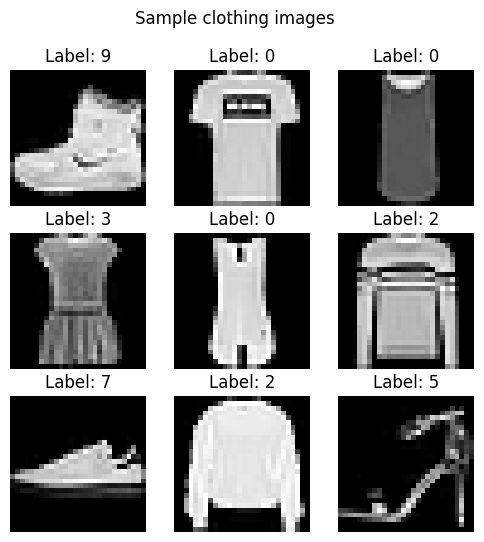

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.suptitle("Sample clothing images")
plt.show()

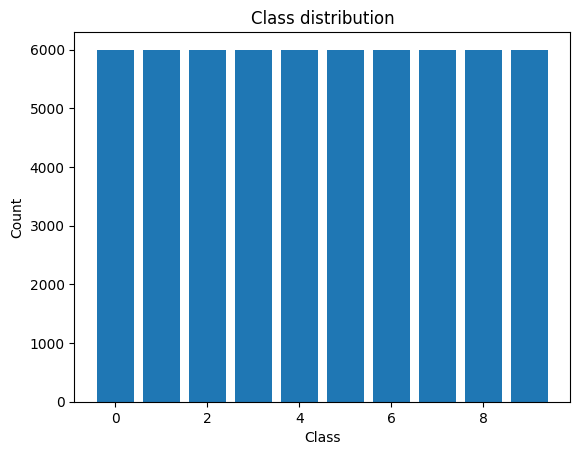

In [ ]:
# check class balance
unique, counts = np.unique(y_train, return_counts=True)
plt.figure()
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation= 'relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8173 - loss: 0.5185 - val_accuracy: 0.8572 - val_loss: 0.4061
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8619 - loss: 0.3856 - val_accuracy: 0.8545 - val_loss: 0.4082
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8737 - loss: 0.3485 - val_accuracy: 0.8701 - val_loss: 0.3574
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8812 - loss: 0.3224 - val_accuracy: 0.8667 - val_loss: 0.3635
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8891 - loss: 0.3009 - val_accuracy: 0.8749 - val_loss: 0.3559
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8946 - loss: 0.2853 - val_accuracy: 0.8791 - val_loss: 0.3255
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8994 - loss: 0.2721 - val_accuracy: 0.8858 - val_loss: 0.3325
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9020 - loss: 0.2632

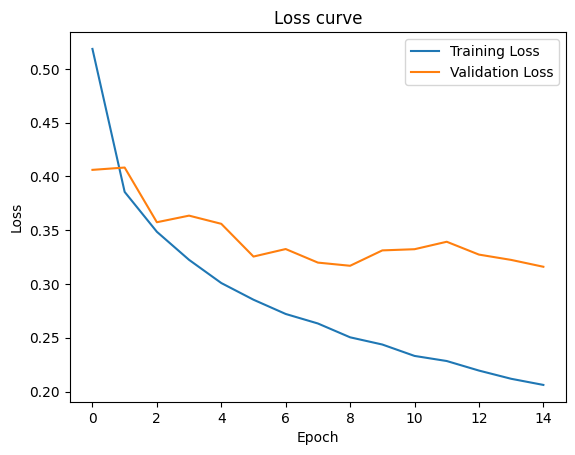

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

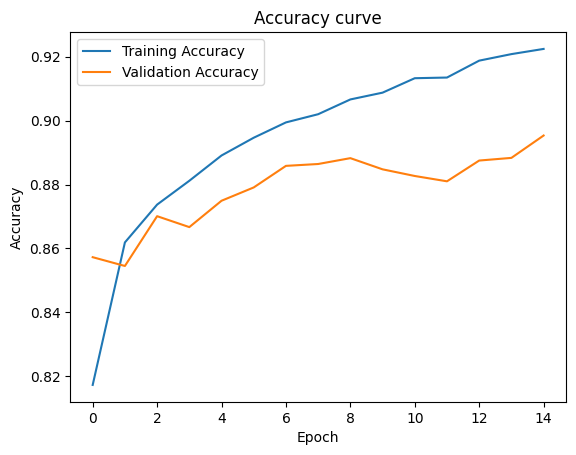

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy :", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8866 - loss: 0.3473
Test accuracy : 0.8866000175476074


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


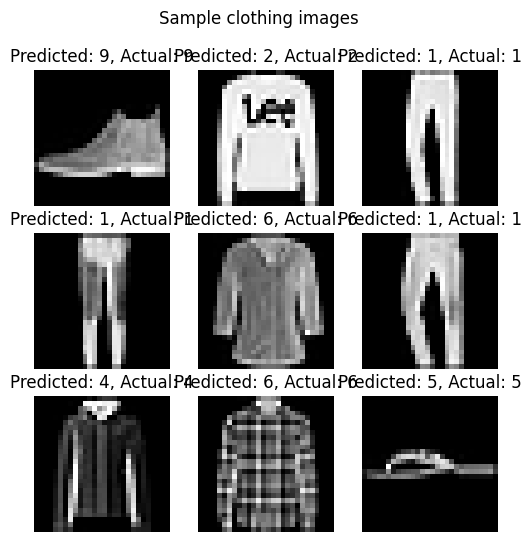

In [ ]:
preds= model.predict(X_test[:9])
plt.figure(figsize=(6,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_test[i], cmap='gray')
  plt.title(f"Predicted: {np.argmax(preds[i])}, Actual: {y_test[i]}")
  plt.axis('off')
plt.suptitle("Sample clothing images")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


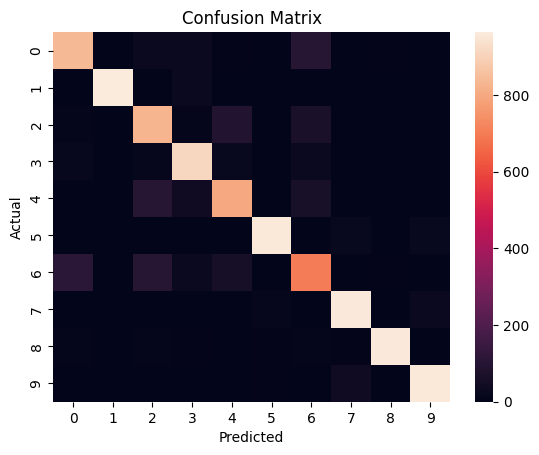

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = np.argmax(model.predict(X_test), axis=1)
cm= confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
